# Task 3 — Distributions and relationships (`penguins.csv`)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,
                     "axes.titlesize":13,"axes.titleweight":"bold","axes.titlelocation":"left"})
NOTE = lambda fig, s: fig.text(0.01, -0.02, s, fontsize=9, color="dimgray", ha="left")   # exclusions / assumptions on the chart
df = pd.read_csv("penguins.csv")
M4 = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]
all_missing = df[df[M4].isna().all(axis=1)]
sex_missing = df[df.sex.isna()]
print("rows:", len(df), "| missing all four measurements:", len(all_missing), "| missing sex:", len(sex_missing))
display(df[df[M4].isna().any(axis=1) | df.sex.isna()])

rows: 344 | missing all four measurements: 2 | missing sex: 11


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


**Decision**
- The penguins missing all four measurements are **dropped from every chart**: they have nothing to plot.
- Penguins missing only `sex` are **kept** for charts 1–3 (they have measurements) and **excluded from chart 4**, which needs sex.
- Nothing is imputed; each chart states how many rows it uses.

In [2]:
d = df.dropna(subset=M4).copy()
species = sorted(d.species.unique()); SP = dict(zip(species, ["#1f77b4", "#ff7f0e", "#2ca02c"]))
print(len(d), "penguins used;", int(d.sex.isna().sum()), "of them have no sex")
means = d.groupby("species").body_mass_g.mean().sort_values(); print(means.round(0))

342 penguins used; 9 of them have no sex
species
Adelie       3701.0
Chinstrap    3733.0
Gentoo       5076.0
Name: body_mass_g, dtype: float64


## 1. Distribution of body mass

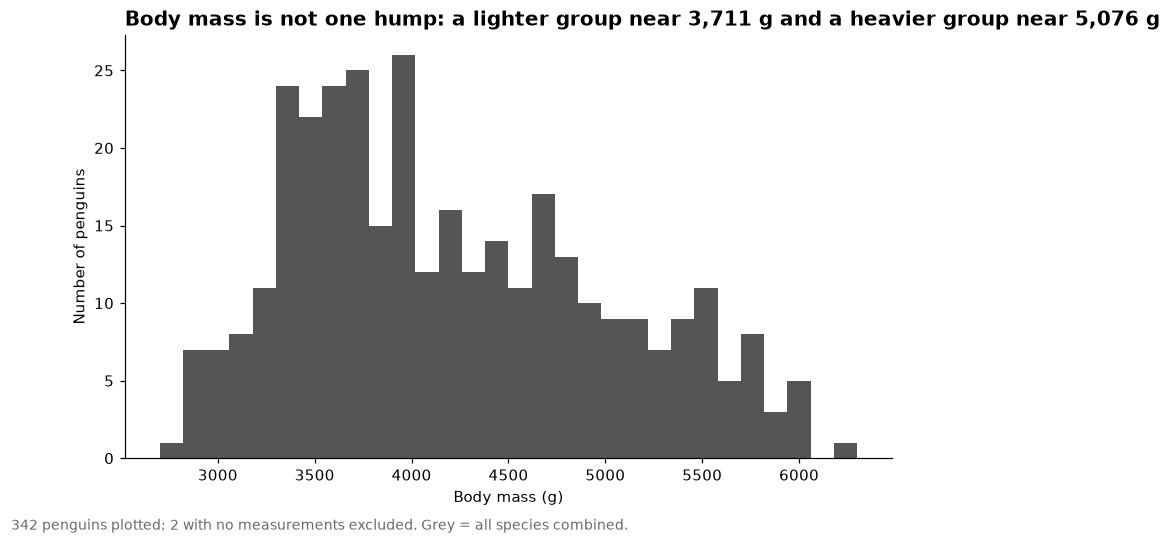

In [3]:
heavy = means.index[-1]; others = d[d.species != heavy].body_mass_g.mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(d.body_mass_g, bins=30, color="#555555"); ax.set_xlabel("Body mass (g)"); ax.set_ylabel("Number of penguins")
ax.set_title(f"Body mass is not one hump: a lighter group near {others:,.0f} g and a heavier group near {means.iloc[-1]:,.0f} g")
NOTE(fig, f"{len(d)} penguins plotted; 2 with no measurements excluded. Grey = all species combined."); plt.show()

**Shape:** more than one hump (a main hump at the lighter masses and a second group at the heavy end), i.e. not a single bell shape.

## 2. Split by species

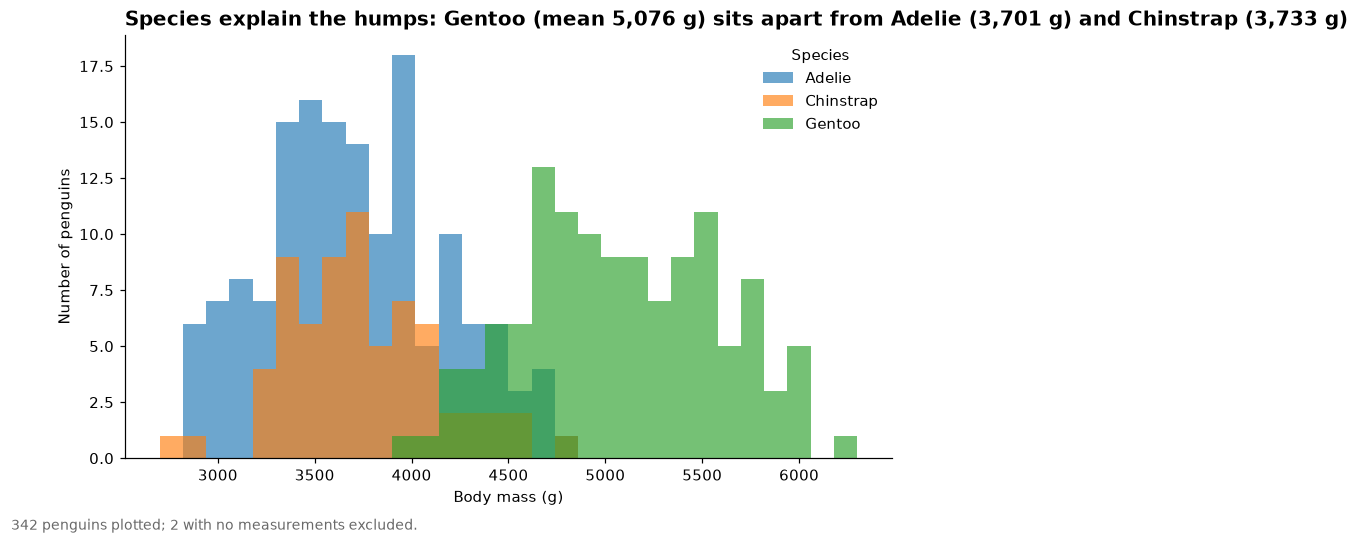

In [4]:
fig, ax = plt.subplots(figsize=(9, 5)); bins = np.histogram_bin_edges(d.body_mass_g, 30)
for s in species: ax.hist(d[d.species==s].body_mass_g, bins=bins, alpha=0.65, color=SP[s], label=s)
ax.legend(title="Species", frameon=False); ax.set_xlabel("Body mass (g)"); ax.set_ylabel("Number of penguins")
ax.set_title(f"Species explain the humps: {heavy} (mean {means.iloc[-1]:,.0f} g) sits apart from {means.index[0]} ({means.iloc[0]:,.0f} g) and {means.index[1]} ({means.iloc[1]:,.0f} g)")
NOTE(fig, f"{len(d)} penguins plotted; 2 with no measurements excluded."); plt.show()

**Yes.** The combined shape is a mixture of species with different typical masses: one species forms the heavy hump and the other two overlap in the lighter one.

## 3. Bill length vs bill depth

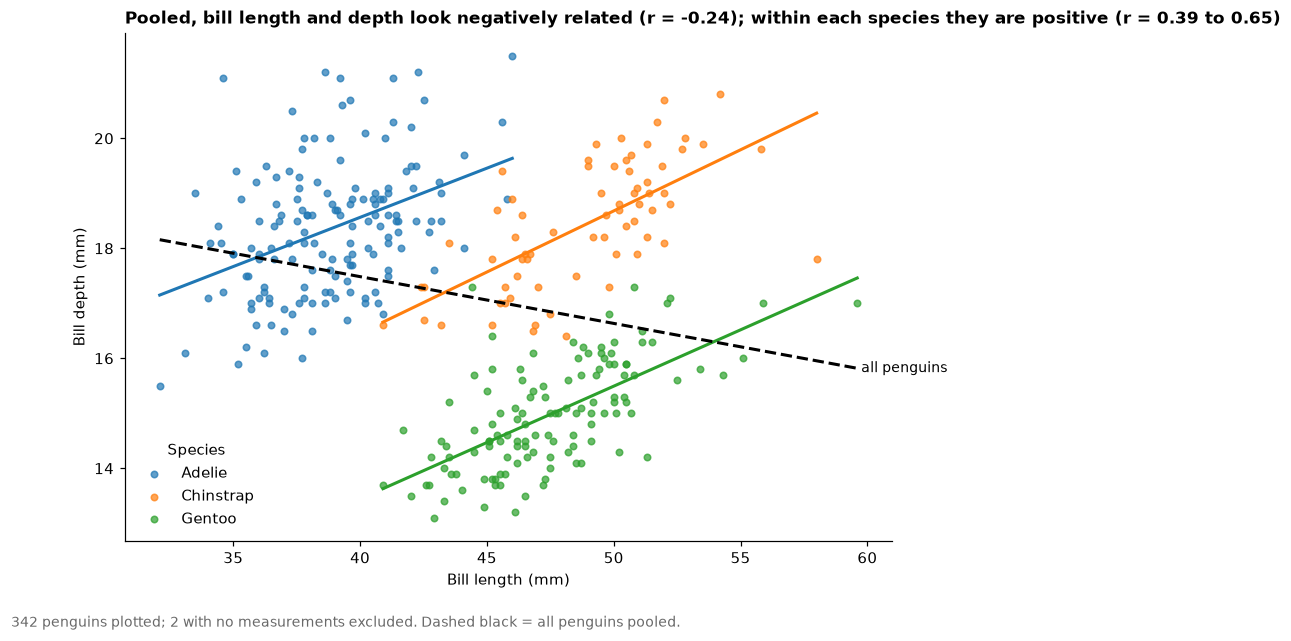

species
Adelie       0.39
Chinstrap    0.65
Gentoo       0.64
dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for s in species:
    e = d[d.species==s]; ax.scatter(e.bill_length_mm, e.bill_depth_mm, s=18, alpha=0.7, color=SP[s], label=s)
    k, b = np.polyfit(e.bill_length_mm, e.bill_depth_mm, 1); xs = np.array([e.bill_length_mm.min(), e.bill_length_mm.max()]); ax.plot(xs, k*xs+b, color=SP[s], lw=2)
k, b = np.polyfit(d.bill_length_mm, d.bill_depth_mm, 1); xs = np.array([d.bill_length_mm.min(), d.bill_length_mm.max()])
ax.plot(xs, k*xs+b, color="black", ls="--", lw=2); ax.text(xs[1], k*xs[1]+b, " all penguins", va="center", fontsize=9)
ax.set_xlabel("Bill length (mm)"); ax.set_ylabel("Bill depth (mm)"); ax.legend(title="Species", frameon=False)
r_all = d.bill_length_mm.corr(d.bill_depth_mm); r_in = d.groupby("species").apply(lambda e: e.bill_length_mm.corr(e.bill_depth_mm), include_groups=False)
ax.set_title(f"Pooled, bill length and depth look negatively related (r = {r_all:.2f}); within each species they are positive (r = {r_in.min():.2f} to {r_in.max():.2f})", fontsize=11)
NOTE(fig, f"{len(d)} penguins plotted; 2 with no measurements excluded. Dashed black = all penguins pooled."); plt.show(); print(r_in.round(2))

**What is going on (Simpson's paradox):** the species differ in both bill measurements and in how they combine: one species has long but shallow bills, the others shorter and deeper bills. Pooling the species mixes these clusters, and the line through the clusters slopes down even though inside each cluster longer bills go with deeper bills. The trend in the pooled data is driven by the *differences between* groups, not the relationship *within* them. Plotting groups separately (colouring by species) reveals it.

## 4. Average body mass by species and sex

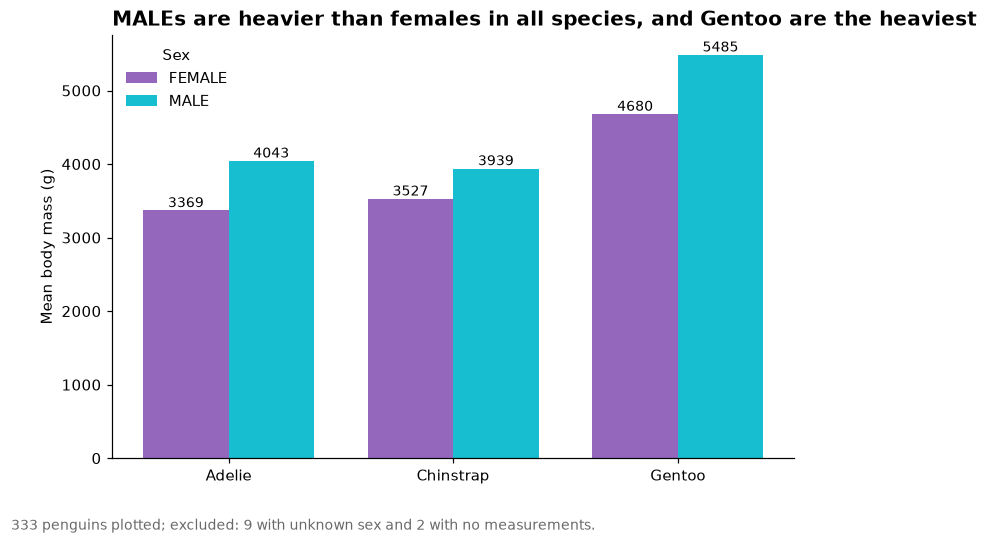

In [6]:
e = d.dropna(subset=["sex"]); sexes = sorted(e.sex.unique()); mean_ss = e.groupby(["species","sex"]).body_mass_g.mean().unstack()[sexes]
fig, ax = plt.subplots(figsize=(8, 5)); w = 0.38; x = np.arange(len(species))
for i, s in enumerate(sexes):
    bars = ax.bar(x + (i-0.5)*w, mean_ss.loc[species, s], w, label=s, color=["#9467bd", "#17becf"][i])
    ax.bar_label(bars, fmt="%.0f", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(species); ax.set_ylim(0, None); ax.set_ylabel("Mean body mass (g)"); ax.legend(title="Sex", frameon=False)
allm = (mean_ss[sexes[1]] > mean_ss[sexes[0]]).all()
ax.set_title(f"{sexes[1]}s are heavier than {sexes[0].lower()}s in {'all' if allm else 'not all'} species, and {means.index[-1]} are the heaviest")
NOTE(fig, f"{len(e)} penguins plotted; excluded: {len(d)-len(e)} with unknown sex and 2 with no measurements."); plt.show()

The step-3 pattern is the strongest argument for plotting groups separately: the pooled picture (negative) was wrong about every individual group (positive).